Mounted at /content/drive
DyS-CNN: TABLE VI (S-BOX PROPERTIES) + FIGURE 3

 Original S-box loaded (256 elements)
   First 16 elements: [16, 64, 111, 221, 21, 69, 187, 89, 108, 14, 244, 24, 67, 7, 235, 206]

 Loading FIXED modified S-box from: /content/drive/My Drive/imagenes_resultados_DySCNN_2026/sbox_mod_fixed_seed42.npy
 Modified S-box loaded (256 elements)
   First 16 elements: [16, 111, 64, 221, 21, 69, 89, 187, 108, 14, 244, 24, 7, 67, 62, 125]

COMPUTING S-BOX CRYPTOGRAPHIC PROPERTIES...

TABLE VI: CRYPTOGRAPHIC PROPERTIES OF THE CNN-GENERATED S-BOX
Property                            Value                Ideal Reference     
--------------------------------------------------------------------------------
Non-linearity (minimum)             105.62               >= 100              
Non-linearity (average)             111.65               ~ 112 (AES = 112)   
SAC (average)                       0.4971               ~ 0.5               
SAC (minimum)                       0.3906  

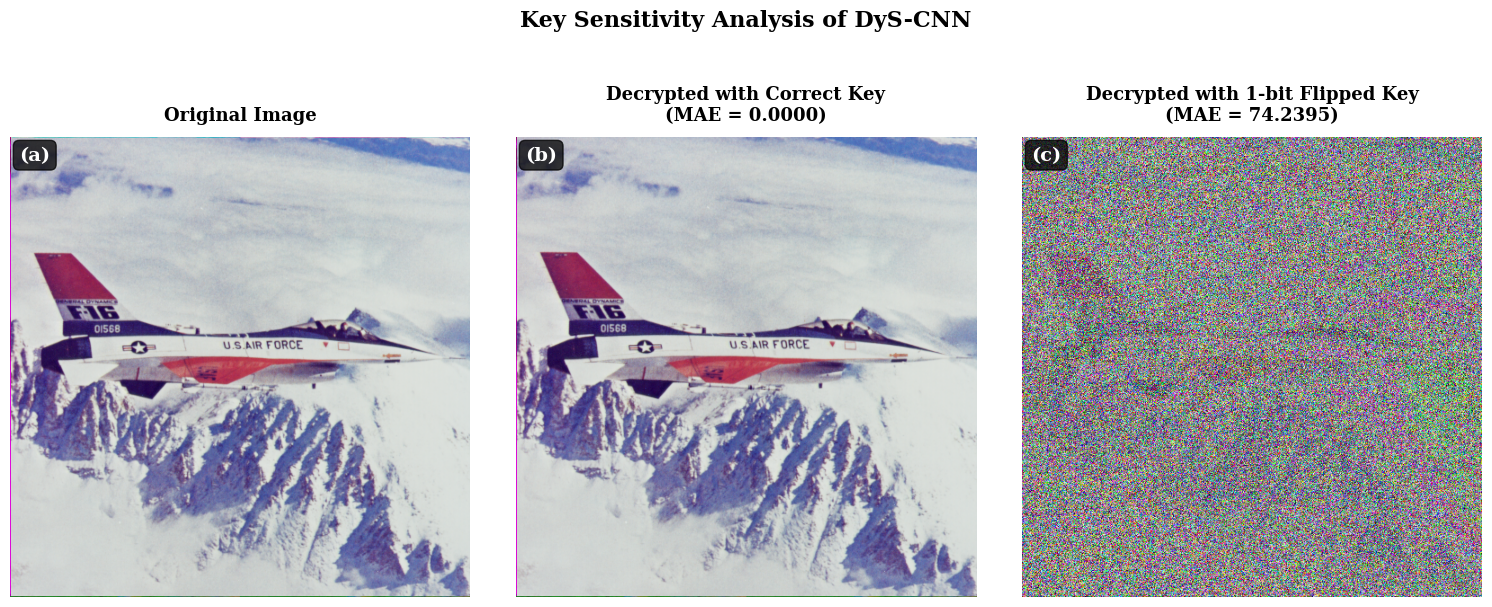


 ALL ANALYSES COMPLETE — FULLY REPRODUCIBLE

 Persisted files (reproducible across all runs):
    sbox_fixed_seed42.npy (original S-box)
    sbox_mod_fixed_seed42.npy (modified S-box)


In [1]:
"""
================================================================================
DyS-CNN: TABLE VI + FIGURE 3 (FULLY REPRODUCIBLE)
Both the original S-box AND the modified S-box are persisted to disk
to guarantee identical results across all runs.
================================================================================
"""

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from PIL import Image
from google.colab import drive

# ============================================
# 0. MOUNT DRIVE
# ============================================
drive.mount('/content/drive')

RUTA_IMAGENES = "/content/drive/My Drive/img_2026"
RUTA_SALIDA = "/content/drive/My Drive/imagenes_resultados_DySCNN_2026"
SBOX_FILE = os.path.join(RUTA_SALIDA, "sbox_fixed_seed42.npy")
SBOX_MOD_FILE = os.path.join(RUTA_SALIDA, "sbox_mod_fixed_seed42.npy")
os.makedirs(RUTA_SALIDA, exist_ok=True)

# ============================================
# 1. PUBLICATION-QUALITY SETTINGS
# ============================================
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size'] = 11
mpl.rcParams['savefig.dpi'] = 300

print("=" * 80)
print("DyS-CNN: TABLE VI (S-BOX PROPERTIES) + FIGURE 3")
print("=" * 80)

# ============================================
# 2. LOAD FIXED ORIGINAL S-BOX
# ============================================
sbox = np.load(SBOX_FILE)
sbox_inv = np.argsort(sbox).astype(np.uint8)
print(f"\n Original S-box loaded ({len(sbox)} elements)")
print(f"   First 16 elements: {sbox[:16].tolist()}")

# ============================================
# 3. CNN MODEL + MODIFIED S-BOX (PERSISTED)
# ============================================
SEED = 42

def create_cnn_sbox_model(seed=SEED):
    initializer = tf.keras.initializers.GlorotUniform(seed=seed)
    return models.Sequential([
        layers.Input(shape=(16, 16, 1)),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same',
                      kernel_initializer=initializer),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      kernel_initializer=initializer),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_initializer=initializer),
        layers.Dense(256, activation='linear', kernel_initializer=initializer)
    ])

def generate_sbox_cnn(seed, model):
    rng = np.random.default_rng(seed)
    input_tensor = rng.random((1, 16, 16, 1)).astype(np.float32)
    output = model(input_tensor, training=False).numpy().flatten()
    return np.argsort(output).astype(np.uint8)

# Load or generate the MODIFIED S-box (persisted to disk)
if os.path.exists(SBOX_MOD_FILE):
    print(f"\n Loading FIXED modified S-box from: {SBOX_MOD_FILE}")
    sbox_mod = np.load(SBOX_MOD_FILE)
else:
    print(f"\n Modified S-box not found. Generating with flipped seed...")
    model_temp = create_cnn_sbox_model(SEED)
    sbox_mod = generate_sbox_cnn(SEED ^ 1, model_temp)
    np.save(SBOX_MOD_FILE, sbox_mod)
    print(f" Modified S-box saved to: {SBOX_MOD_FILE}")

sbox_wrong_inv = np.argsort(sbox_mod).astype(np.uint8)
print(f" Modified S-box loaded ({len(sbox_mod)} elements)")
print(f"   First 16 elements: {sbox_mod[:16].tolist()}")

# ============================================
# 4. S-BOX CRYPTOGRAPHIC PROPERTY FUNCTIONS
# ============================================
def calculate_non_linearity(sbox):
    n = 8
    truth = np.zeros((n, 256), dtype=int)
    for x in range(256):
        y = int(sbox[x])
        for i in range(n):
            truth[i, x] = (y >> i) & 1
    nl_vals = []
    for i in range(n):
        f = 1 - 2 * truth[i]
        wht = np.fft.fft(f).real
        nl_vals.append(128 - np.max(np.abs(wht)) / 2)
    return np.min(nl_vals), np.mean(nl_vals)

def calculate_SAC(sbox):
    n = 8
    sac = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            changes = sum(((int(sbox[x]) >> j) & 1) !=
                          ((int(sbox[x ^ (1 << i)]) >> j) & 1)
                          for x in range(256))
            sac[i, j] = changes / 256
    return sac

def calculate_BIC(sbox):
    n = 8
    bic = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            changes = 0
            for x in range(256):
                y1, y2 = int(sbox[x]), int(sbox[x ^ 0xFF])
                if (((y1 >> i) & 1) != ((y2 >> i) & 1)) != \
                   (((y1 >> j) & 1) != ((y2 >> j) & 1)):
                    changes += 1
            bic[i, j] = bic[j, i] = changes / 256
    od = bic[np.triu_indices(8, k=1)]
    return np.mean(od), np.max(np.abs(od - 0.5))

def calculate_diff_uniformity(sbox):
    ddt = np.zeros((256, 256), dtype=int)
    for dx in range(256):
        for x in range(256):
            ddt[dx, int(sbox[x]) ^ int(sbox[x ^ dx])] += 1
    return int(np.max(ddt[1:, :]))

# ============================================
# 5. COMPUTE S-BOX PROPERTIES
# ============================================
print("\n" + "=" * 80)
print("COMPUTING S-BOX CRYPTOGRAPHIC PROPERTIES...")
print("=" * 80)

nl_min, nl_avg = calculate_non_linearity(sbox)
sac = calculate_SAC(sbox)
bic_avg, bic_max_dev = calculate_BIC(sbox)
diff_uniform = calculate_diff_uniformity(sbox)

# Key sensitivity (using the FIXED modified S-box)
diff_vals = int(np.sum(sbox != sbox_mod))
diff_pct = 100 * diff_vals / 256
hamming = int(np.sum([bin(int(a) ^ int(b)).count('1')
                      for a, b in zip(sbox, sbox_mod)]))

# Key space
key_space = 2 ** 256
years_bruteforce = key_space / (1e12 * 3.15e7)

# ============================================
# 6. PRINT TABLE VI
# ============================================
print("\n" + "=" * 80)
print("TABLE VI: CRYPTOGRAPHIC PROPERTIES OF THE CNN-GENERATED S-BOX")
print("=" * 80)
print(f"{'Property':<35} {'Value':<20} {'Ideal Reference':<20}")
print("-" * 80)
print(f"{'Non-linearity (minimum)':<35} {nl_min:<20.2f} {'>= 100':<20}")
print(f"{'Non-linearity (average)':<35} {nl_avg:<20.2f} {'~ 112 (AES = 112)':<20}")
print(f"{'SAC (average)':<35} {np.mean(sac):<20.4f} {'~ 0.5':<20}")
print(f"{'SAC (minimum)':<35} {np.min(sac):<20.4f} {'~ 0.5':<20}")
print(f"{'BIC (average)':<35} {bic_avg:<20.4f} {'~ 0.5':<20}")
print(f"{'BIC (maximum deviation)':<35} {bic_max_dev:<20.4f} {'~ 0':<20}")
print(f"{'Differential uniformity':<35} {diff_uniform:<20} {'<= 10 (acceptable)':<20}")
print(f"{'Key space':<35} {'2^256':<20} {'>= 2^128':<20}")
print(f"{'Key sensitivity':<35} {f'{diff_pct:.2f}%':<20} {'> 50%':<20}")
print("=" * 80)

print("\n" + "=" * 80)
print("PLAIN TEXT VERSION (copy-paste to manuscript)")
print("=" * 80)
print(f"Non-linearity (minimum)     : {nl_min:.2f}")
print(f"Non-linearity (average)     : {nl_avg:.2f}")
print(f"SAC (average)               : {np.mean(sac):.4f}")
print(f"SAC (minimum)               : {np.min(sac):.4f}")
print(f"BIC (average)               : {bic_avg:.4f}")
print(f"BIC (maximum deviation)     : {bic_max_dev:.4f}")
print(f"Differential uniformity     : {diff_uniform}")
print(f"Key space                   : 2^256")
print(f"Key sensitivity             : {diff_pct:.2f}%")
print(f"S-box values changed        : {diff_vals}/256")
print(f"Hamming distance            : {hamming}")
print("=" * 80)

# ============================================
# 7. KEY SENSITIVITY EXPERIMENT (for Figure 3)
# ============================================
def diffusion_forward(img):
    flat = img.flatten()
    accum = 0
    out = np.zeros_like(flat, dtype=np.uint8)
    for i in range(len(flat)):
        accum = (accum + int(flat[i])) % 256
        out[i] = accum
    return out.reshape(img.shape).astype(np.uint8)

def diffusion_inverse(img):
    flat = img.flatten()
    prev_accum = 0
    out = np.zeros_like(flat, dtype=np.uint8)
    for i in range(len(flat)):
        original = (int(flat[i]) - prev_accum) % 256
        prev_accum = int(flat[i])
        out[i] = original
    return out.reshape(img.shape).astype(np.uint8)

def round_encrypt(img, sbox, seed):
    h, w, c = img.shape
    img_sub = sbox[img]
    rng = np.random.default_rng(seed)
    indices = rng.permutation(h * w * c)
    img_perm = img_sub.flatten()[indices].reshape(h, w, c)
    rng = np.random.default_rng(seed)
    key = rng.integers(0, 256, (h, w, c), dtype=np.uint8)
    return diffusion_forward(np.bitwise_xor(img_perm, key))

def round_decrypt(img, sbox_inv, seed):
    h, w, c = img.shape
    img_xor = diffusion_inverse(img)
    rng = np.random.default_rng(seed)
    key = rng.integers(0, 256, (h, w, c), dtype=np.uint8)
    img_perm = np.bitwise_xor(img_xor, key)
    rng = np.random.default_rng(seed)
    indices = rng.permutation(h * w * c)
    flat = img_perm.flatten()[np.argsort(indices)]
    return sbox_inv[flat.reshape(h, w, c)]

def encrypt_image(img, sbox, seed1=42, seed2=43):
    img = img.astype(np.uint8)
    return round_encrypt(round_encrypt(img, sbox, seed1), sbox, seed2)

def decrypt_image(img_enc, sbox_inv, seed1=42, seed2=43):
    img = img_enc.astype(np.uint8)
    return round_decrypt(round_decrypt(img, sbox_inv, seed2), sbox_inv, seed1)

def calculate_mae(a, b):
    return np.mean(np.abs(a.astype(np.float64) - b.astype(np.float64)))

print("\n" + "=" * 80)
print("KEY SENSITIVITY EXPERIMENT (for Figure 3)")
print("=" * 80)

name = "airplane"
img_original = np.array(Image.open(os.path.join(RUTA_IMAGENES, f"{name}.png")).convert('RGB'))

img_encrypted = encrypt_image(img_original, sbox, 42, 43)
img_dec_correct = decrypt_image(img_encrypted, sbox_inv, 42, 43)
img_dec_wrong = decrypt_image(img_encrypted, sbox_wrong_inv, 42, 43)

mae_correct = calculate_mae(img_original, img_dec_correct)
mae_wrong = calculate_mae(img_original, img_dec_wrong)

print(f"MAE (correct key) : {mae_correct:.6f}")
print(f"MAE (wrong key)   : {mae_wrong:.4f}")

# ============================================
# 8. CREATE FIGURE 3
# ============================================
print("\n" + "=" * 80)
print("GENERATING FIGURE 3 (300 DPI, LZW compression)")
print("=" * 80)

fig = plt.figure(figsize=(16, 7))
gs = GridSpec(1, 3, figure=fig, top=0.80, bottom=0.05,
              left=0.04, right=0.96, wspace=0.10)

fig.text(0.5, 0.92, "Key Sensitivity Analysis of DyS-CNN",
         ha='center', va='center', fontsize=16, fontweight='bold')

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img_original)
ax1.set_title("Original Image", fontsize=13, fontweight='bold', pad=12)
ax1.axis('off')
ax1.text(0.02, 0.98, "(a)", transform=ax1.transAxes,
         fontsize=14, fontweight='bold', va='top', ha='left',
         color='white', bbox=dict(boxstyle='round,pad=0.3',
                                   facecolor='black', alpha=0.75))

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(img_dec_correct)
ax2.set_title(f"Decrypted with Correct Key\n(MAE = {mae_correct:.4f})",
              fontsize=13, fontweight='bold', pad=12)
ax2.axis('off')
ax2.text(0.02, 0.98, "(b)", transform=ax2.transAxes,
         fontsize=14, fontweight='bold', va='top', ha='left',
         color='white', bbox=dict(boxstyle='round,pad=0.3',
                                   facecolor='black', alpha=0.75))

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(img_dec_wrong)
ax3.set_title(f"Decrypted with 1-bit Flipped Key\n(MAE = {mae_wrong:.4f})",
              fontsize=13, fontweight='bold', pad=12)
ax3.axis('off')
ax3.text(0.02, 0.98, "(c)", transform=ax3.transAxes,
         fontsize=14, fontweight='bold', va='top', ha='left',
         color='white', bbox=dict(boxstyle='round,pad=0.3',
                                   facecolor='black', alpha=0.75))

# ============================================
# 9. SAVE
# ============================================
ruta_tiff = os.path.join(RUTA_SALIDA, "fig3_key_sensitivity.tiff")
ruta_png = os.path.join(RUTA_SALIDA, "fig3_key_sensitivity.png")
ruta_pdf = os.path.join(RUTA_SALIDA, "fig3_key_sensitivity.pdf")

fig.savefig(ruta_tiff, dpi=300, format='tiff',
            bbox_inches='tight', pad_inches=0.15,
            facecolor='white', pil_kwargs={"compression": "tiff_lzw"})
print(f"\n TIFF (300 DPI, LZW): {ruta_tiff}")

fig.savefig(ruta_png, dpi=300, format='png',
            bbox_inches='tight', pad_inches=0.15,
            facecolor='white', pil_kwargs={"optimize": True})
print(f" PNG  (300 DPI)     : {ruta_png}")

fig.savefig(ruta_pdf, format='pdf',
            bbox_inches='tight', pad_inches=0.15, facecolor='white')
print(f" PDF  (vector)      : {ruta_pdf}")

plt.show()
plt.close()

# ============================================
# 10. FINAL VERDICT
# ============================================
print("\n" + "=" * 80)
print(" ALL ANALYSES COMPLETE — FULLY REPRODUCIBLE")
print("=" * 80)
print(f"\n Persisted files (reproducible across all runs):")
print(f"    sbox_fixed_seed42.npy (original S-box)")
print(f"    sbox_mod_fixed_seed42.npy (modified S-box)")
print("=" * 80)